<h3 style="color: #e0e0ff; font-style: italic;">📝 Cross-modal Ambiguity Learning for Multimodal Fake News Detection</h3>

---

**Problem Statement & Challenges**

- Fake news on social media often contains cross-modal inconsistencies between text and images (e.g., a real image with fake caption, or AI-generated image with contradictory text).

- Existing multi-modal fusion methods have two key limitations:
   - Challenge 1: Treat image and text as equally reliable, failing to detect when they contradict each other.
   - Challenge 2: Use deterministic fusion (e.g., concatenation, attention) without modeling uncertainty or ambiguity between modalities.

So, **CAFE** asks: *"Do the image and text agree or contradict each other?"*

1. Each modality gets a "voice" (separate image-only and text-only classifiers)
2. Ambiguity is measured via Kullback-Leibler divergence:

   $D_{KL} = \frac{1}{2} \sum \left( \log\frac{\sigma^2_t}{\sigma^2_v} + \frac{\sigma^2_v + (\mu_v - \mu_t)^2}{\sigma^2_t} - 1 \right)$  
   → **0 = agree, large = contradict**

3. **High disagreement** → trusts each modality independently (something's fishy)
4. **Low disagreement** → trusts the combined image+text prediction (they're coherent)

**Simple analogy:** Two witnesses. If their stories match, you trust the combined account. If they contradict, you listen to each separately to spot the liar.

---
**🔧 How It Works**

**Step 1: Extract Embeddings**
- Image → CLIP ViT-B/16 → 768-dim (Frozen)
- Text → XLM-RoBERTa-base → 768-dim (Frozen)

**Step 2: Uncertainty Heads** (Small neural network)
- μ (mean) = "best guess" representation
- σ (variance) = how uncertain (small σ = confident, large σ = unsure)

**Step 3: Project to Common Dimension** (768 and 768 → 256-dim)

**Step 4: KL Divergence**
- D_KL small (≈0) = Image and Text AGREE
- D_KL large = Image and Text CONTRADICT

**Step 5: Adaptive Fusion Decision**

| Condition | Action |
|-----------|--------|
| **AGREE** (D_KL small) | Use FUSED model (image+text together) |
| **DISAGREE** (D_KL large) | Use SEPARATE models (average image + text predictions) |
| **50/50 UNCERTAIN** | Average BOTH approaches |

**Loading libraries**

In [1]:
# Core Imports
import os
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from transformers import XLMRobertaModel, XLMRobertaTokenizer, CLIPVisionModel, CLIPProcessor

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, accuracy_score, precision_recall_fscore_support, roc_curve, auc
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Device: {device}")

🚀 Device: cpu


**Data Preparation**

In [4]:
class M4FCDataset(Dataset):
    def __init__(self, df, tokenizer, processor, max_text_length=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.processor = processor
        self.max_text_length = max_text_length
        self.text_field = 'multilingual_claim'
        print(f"Using text field: {self.text_field}")
    
    def __len__(self):
        return len(self.df)
    
    def load_image(self, image_path):
        """Loading and preprocessing the image using CLIPProcessor"""
        try:
            if os.path.exists(image_path):
                image = Image.open(image_path).convert('RGB')
                # Applying CLIP preprocessor to standardize size, crop and normalization
                pixel_values = self.processor(images=image, return_tensors='pt')['pixel_values'].squeeze(0)
                return pixel_values
            else:
                return torch.zeros(3, 224, 224)
        except Exception as e:
            return torch.zeros(3, 224, 224)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Processing text
        text = str(row[self.text_field]) if pd.notna(row[self.text_field]) else ""
        encoding = self.tokenizer(
            text,
            max_length=self.max_text_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Processing image
        image_path = row['full_image_path'] if pd.notna(row['full_image_path']) else ""
        image = self.load_image(image_path)
        
        # Label
        label = torch.tensor(row['target'], dtype=torch.long)
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'image': image,
            'label': label,
            'text': text,
            'image_path': image_path
        }

In [5]:
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch16')
df = pd.read_csv('../../data/M4FC.csv')
df = df.dropna(subset=['target']).reset_index(drop=True)

print("✅ Loaded M4FC dataset, XLM-RoBERTa tokenizer, and CLIP processor")

✅ Loaded M4FC dataset, XLM-RoBERTa tokenizer, and CLIP processor


In [6]:
# Splitting the Dataframe
indices = np.arange(len(df))
idx_temp, idx_test = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=df['target'].values
)
idx_train, idx_val = train_test_split(
    idx_temp,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=df['target'].values[idx_temp]
)

train_df = df.iloc[idx_train].reset_index(drop=True)
val_df = df.iloc[idx_val].reset_index(drop=True)
test_df = df.iloc[idx_test].reset_index(drop=True)

print(f"✓ Dataset split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

✓ Dataset split: Train=3462, Val=743, Test=743


In [7]:
# Datasets
train_dataset = M4FCDataset(train_df, tokenizer, processor)
val_dataset = M4FCDataset(val_df, tokenizer, processor)
test_dataset = M4FCDataset(test_df, tokenizer, processor)

# Data Loaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Using text field: multilingual_claim
Using text field: multilingual_claim
Using text field: multilingual_claim


**Backbone Models**

In [8]:
print("=" * 50)
print("📥 Loading XLM-RoBERTa...")
print("=" * 50)
text_encoder = XLMRobertaModel.from_pretrained('xlm-roberta-base', use_safetensors=True)
for param in text_encoder.parameters():
    param.requires_grad = False
text_dim = 768
print("✅ XLM-RoBERTa loaded and frozen")

📥 Loading XLM-RoBERTa...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2341.64it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ XLM-RoBERTa loaded and frozen


In [9]:
print("=" * 50)
print("📥 Loading CLIP ViT-B/16...")
print("=" * 50)
image_encoder = CLIPVisionModel.from_pretrained('openai/clip-vit-base-patch16', use_safetensors=True)
for param in image_encoder.parameters():
    param.requires_grad = False
image_dim = 768
print("✅ CLIP ViT-B/16 loaded and frozen")

📥 Loading CLIP ViT-B/16...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1251.29it/s]
[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.w

✅ CLIP ViT-B/16 loaded and frozen


**CAFE Implementation**

In [ ]:
class CAFEModel(nn.Module):
    def __init__(self, text_encoder, image_encoder, img_dim=768, text_dim=768, common_dim=256):
        super().__init__()
        self.text_encoder = text_encoder
        self.image_encoder = image_encoder
        self.common_dim = common_dim
        
        # Single projection head per modality producing [mu, sigma]
        self.text_head = nn.Linear(text_dim, common_dim * 2)
        self.img_head = nn.Linear(img_dim, common_dim * 2)
        
        # Classifiers
        self.fused_classifier = nn.Linear(common_dim * 2, 2)
        self.img_classifier = nn.Linear(common_dim, 2)
        self.text_classifier = nn.Linear(common_dim, 2)
        
    def forward(self, input_ids, attention_mask, image):
        with torch.no_grad():
            text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
            text_emb = text_outputs.last_hidden_state[:, 0, :]
            
            # Retrieving CLIP Vision outputs
            img_outputs = self.image_encoder(pixel_values=image)
            img_emb = img_outputs.pooler_output
            
        t_out = self.text_head(text_emb)
        i_out = self.img_head(img_emb)
        
        # Extracting mu and positive sigma via Softplus stably
        t_mu, t_sigma = t_out[:, :self.common_dim], F.softplus(t_out[:, self.common_dim:]) + 1e-6
        i_mu, i_sigma = i_out[:, :self.common_dim], F.softplus(i_out[:, self.common_dim:]) + 1e-6
        
        # Mean over latent dimensions keeps KL magnitudes scaled naturally
        kl_div = 0.5 * (
            torch.log(t_sigma**2 / i_sigma**2) +
            (i_sigma**2 + (i_mu - t_mu)**2) / t_sigma**2 - 1
        ).mean(dim=1)
        
        fused_pred = self.fused_classifier(torch.cat([i_mu, t_mu], dim=1))
        img_pred = self.img_classifier(i_mu)
        text_pred = self.text_classifier(t_mu)
        
        return fused_pred, img_pred, text_pred, kl_div

**Training Pipeline**

In [ ]:
class CAFETrainer:
    def __init__(self, model, train_loader, val_loader, test_loader, device='cuda', class_weights=None, patience=5):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        # Using ReduceLROnPlateau scheduler for robust plateau adjustment
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=3)
        
        # Loading precomputed class weights
        self.criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)
        
        self.metrics_history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'precision': [], 'recall': [], 'f1': [],
            'auc': [], 'kl_divergence': [],
            'support': []
        }
        self.best_model_path = '../../models/cafe/best_cafe_model.pt'
        self.best_val_f1 = 0.0
        self.best_val_acc = 0.0
        self.patience = patience
        
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        predictions = []
        labels_list = []
        
        progress_bar = tqdm(self.train_loader, desc='Training')
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            image = batch['image'].to(self.device)
            label = batch['label'].to(self.device)
            
            self.optimizer.zero_grad()
            fused_pred, img_pred, text_pred, kl_div = self.model(input_ids, attention_mask, image)
            
            # Standard classification losses on linear predictions
            loss_fused = self.criterion(fused_pred, label)
            loss_img = self.criterion(img_pred, label)
            loss_text = self.criterion(text_pred, label)
            
            # Soft-gating applied at training to optimize the routed prediction directly (with temperature 5.0)
            skl = torch.sigmoid(kl_div / 5.0).unsqueeze(1)
            fused_prob = F.softmax(fused_pred, dim=1)
            img_prob = F.softmax(img_pred, dim=1)
            text_prob = F.softmax(text_pred, dim=1)
            unimodal_prob = 0.5 * (img_prob + text_prob)
            final_prob = (1.0 - skl) * fused_prob + skl * unimodal_prob
            
            loss_gated = F.nll_loss(torch.log(final_prob + 1e-8), label, weight=self.criterion.weight)
            loss = loss_gated + 0.3 * (loss_fused + loss_img + loss_text)
            
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            
            _, preds = torch.max(final_prob.detach(), 1)
            predictions.extend(preds.cpu().numpy())
            labels_list.extend(label.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
            
        avg_loss = total_loss / len(self.train_loader)
        accuracy = accuracy_score(labels_list, predictions)
        return avg_loss, accuracy
        
    @torch.no_grad()
    def evaluate(self, loader, mode='val'):
        self.model.eval()
        total_loss = 0
        predictions = []
        probabilities = []
        labels_list = []
        kls_list = []
        
        for batch in tqdm(loader, desc=f'Evaluating {mode}'):
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            image = batch['image'].to(self.device)
            label = batch['label'].to(self.device)
            
            fused_pred, img_pred, text_pred, kl_div = self.model(input_ids, attention_mask, image)
            
            loss_fused = self.criterion(fused_pred, label)
            loss_img = self.criterion(img_pred, label)
            loss_text = self.criterion(text_pred, label)
            
            # Soft-gating applied at evaluation/inference with temperature 5.0
            skl = torch.sigmoid(kl_div / 5.0).unsqueeze(1)
            fused_prob = F.softmax(fused_pred, dim=1)
            img_prob = F.softmax(img_pred, dim=1)
            text_prob = F.softmax(text_pred, dim=1)
            unimodal_prob = 0.5 * (img_prob + text_prob)
            final_prob = (1.0 - skl) * fused_prob + skl * unimodal_prob
            
            loss_gated = F.nll_loss(torch.log(final_prob + 1e-8), label, weight=self.criterion.weight)
            loss = loss_gated + 0.3 * (loss_fused + loss_img + loss_text)
            
            total_loss += loss.item()
            
            probs = final_prob[:, 1]
            _, preds = torch.max(final_prob, 1)
            
            predictions.extend(preds.cpu().numpy())
            probabilities.extend(probs.cpu().numpy())
            labels_list.extend(label.cpu().numpy())
            kls_list.extend(kl_div.cpu().numpy())
            
        avg_loss = total_loss / len(loader)
        accuracy = accuracy_score(labels_list, predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels_list, predictions, average='binary', zero_division=0
        )
        auc_score = roc_auc_score(labels_list, probabilities)
        
        # Extracting the positive class support as an integer directly from the labels
        positive_support = int(np.sum(np.array(labels_list) == 1))
        
        return {
            'loss': avg_loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc_score,
            'support': positive_support,
            'kl_mean': np.mean(kls_list),
            'predictions': predictions,
            'true_labels': labels_list,
            'probabilities': probabilities,
            'kl_divergence': kls_list
        }

    def train(self, epochs=30):
        print("Starting CAFE Training Pipeline...")
        print("=" * 50)
        
        os.makedirs(os.path.dirname(self.best_model_path), exist_ok=True)
        patience_counter = 0
        self.best_val_f1 = 0.0
        self.best_val_acc = 0.0  # reset best validation accuracy
        
        start_time = time.time()
        for epoch in range(epochs):
            epoch_start = time.time()
            print(f"\nEpoch {epoch + 1}/{epochs}")
            print("-" * 30)
            
            train_loss, train_acc = self.train_epoch()
            val_metrics = self.evaluate(self.val_loader, 'val')
            
            # Step the scheduler based on validation loss
            self.scheduler.step(val_metrics['loss'])
            
            self.metrics_history['train_loss'].append(train_loss)
            self.metrics_history['train_acc'].append(train_acc)
            self.metrics_history['val_loss'].append(val_metrics['loss'])
            self.metrics_history['val_acc'].append(val_metrics['accuracy'])
            self.metrics_history['precision'].append(val_metrics['precision'])
            self.metrics_history['recall'].append(val_metrics['recall'])
            self.metrics_history['f1'].append(val_metrics['f1'])
            self.metrics_history['auc'].append(val_metrics['auc'])
            self.metrics_history['kl_divergence'].append(val_metrics['kl_mean'])
            self.metrics_history['support'].append(val_metrics['support'])
            
            epoch_time = time.time() - epoch_start
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}")
            print(f"Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}")
            print(f"F1-Score: {val_metrics['f1']:.4f}, AUC: {val_metrics['auc']:.4f}")
            print(f"Support: {val_metrics['support']}")
            print(f"⏱️ Epoch time: {epoch_time:.2f} seconds")
            
            if val_metrics['f1'] > self.best_val_f1:
                self.best_val_f1 = val_metrics['f1']
                self.best_val_acc = val_metrics['accuracy']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_accuracy': val_metrics['accuracy'],
                    'val_loss': val_metrics['loss'],
                }, self.best_model_path)
                print(f"✓ Best model saved with val_acc: {val_metrics['accuracy']:.4f}")
                patience_counter = 0
            else:
                patience_counter += 1
                print(f"⚠️ No improvement for {patience_counter}/{self.patience} epochs")
                if patience_counter >= self.patience:
                    print(f"\n🛑 Early stopping triggered after {epoch + 1} epochs!")
                    break
                    
        total_time = time.time() - start_time
        print("\n" + "=" * 50)
        print(f"Training completed in {total_time/60:.2f} minutes!")
        print(f"Best validation accuracy: {self.best_val_acc:.4f}")
        print("=" * 50)
        return self.metrics_history


In [12]:
# Computing class weights from dataframe
targets = train_df['target'].values
num_real = np.sum(targets == 0)
num_fake = np.sum(targets == 1)

weight_real = 1.0 / num_real if num_real > 0 else 1.0
weight_fake = 1.0 / num_fake if num_fake > 0 else 1.0
class_weights = torch.tensor([weight_real, weight_fake], dtype=torch.float)
# class_weights = class_weights / class_weights.sum()  # Keep unnormalized class weights as requested
print(f"✓ Precomputed class weights: {class_weights.tolist()}")

print("Initializing CAFE model...")
cafe_model = CAFEModel(text_encoder, image_encoder).to(device)

trainer = CAFETrainer(cafe_model, train_loader, val_loader, test_loader, device, class_weights=class_weights, patience=5)
metrics_history = trainer.train(epochs=30)

✓ Precomputed class weights: [0.0049019609577953815, 0.0003069367667194456]
Initializing CAFE model...
Starting CAFE Training Pipeline...

Epoch 1/30
------------------------------


Evaluating val: 100%|██████████| 47/47 [05:30<00:00,  7.03s/it]


Train Loss: 1.0891, Train Acc: 0.9191
Val Loss: 0.9069, Val Acc: 0.9166
Precision: 0.9733, Recall: 0.9371
F1-Score: 0.9548, AUC: 0.9049
Support: 699
⏱️ Epoch time: 2340.32 seconds
✓ Best model saved with val_acc: 0.9166

Epoch 2/30
------------------------------


Evaluating val: 100%|██████████| 47/47 [05:05<00:00,  6.50s/it]


Train Loss: 0.8860, Train Acc: 0.9041
Val Loss: 0.9019, Val Acc: 0.9314
Precision: 0.9779, Recall: 0.9485
F1-Score: 0.9630, AUC: 0.9150
Support: 699
⏱️ Epoch time: 2195.06 seconds
✓ Best model saved with val_acc: 0.9314

Epoch 3/30
------------------------------


...

Train Loss: 0.8084, Train Acc: 0.9376
Val Loss: 0.9239, Val Acc: 0.8883
Precision: 0.9753, Recall: 0.9041
F1-Score: 0.9384, AUC: 0.9030
Support: 699
⏱️ Epoch time: 2366.48 seconds
⚠️ No improvement for 3/5 epochs

Epoch 6/30
------------------------------


Evaluating val: 100%|██████████| 47/47 [05:31<00:00,  7.05s/it]


Train Loss: 0.7448, Train Acc: 0.9373
Val Loss: 0.9672, Val Acc: 0.9044
Precision: 0.9758, Recall: 0.9213
F1-Score: 0.9478, AUC: 0.9058
Support: 699
⏱️ Epoch time: 2444.88 seconds
⚠️ No improvement for 4/5 epochs

Epoch 7/30
------------------------------


Evaluating val: 100%|██████████| 47/47 [05:26<00:00,  6.94s/it]

Train Loss: 0.6819, Train Acc: 0.9454
Val Loss: 1.1190, Val Acc: 0.9219
Precision: 0.9720, Recall: 0.9442
F1-Score: 0.9579, AUC: 0.8989
Support: 699
⏱️ Epoch time: 2315.31 seconds
⚠️ No improvement for 5/5 epochs

🛑 Early stopping triggered after 7 epochs!

Training completed in 276.95 minutes!
Best validation accuracy: 0.9314


**Evaluation & Visualizations**

In [13]:
class CAFEVisualizer:
    @staticmethod
    def plot_training_history(metrics_history, save_path='training_history.png'):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        axes[0, 0].plot(metrics_history['train_loss'], label='Train Loss')
        axes[0, 0].plot(metrics_history['val_loss'], label='Val Loss')
        axes[0, 0].set_title('Loss Over Time')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].plot(metrics_history['train_acc'], label='Train Acc')
        axes[0, 1].plot(metrics_history['val_acc'], label='Val Acc')
        axes[0, 1].set_title('Accuracy Over Time')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].plot(metrics_history['f1'], label='F1-Score', marker='o')
        axes[1, 0].plot(metrics_history['auc'], label='AUC', marker='s')
        axes[1, 0].set_title('F1-Score and AUC')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].plot(metrics_history['precision'], label='Precision', marker='^')
        axes[1, 1].plot(metrics_history['recall'], label='Recall', marker='v')
        axes[1, 1].set_title('Precision-Recall Trade-off')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ Training history plot saved to {save_path}")
        
    @staticmethod
    def plot_confusion_matrix(y_true, y_pred, save_path='confusion_matrix.png'):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Real', 'Fake'],
                   yticklabels=['Real', 'Fake'])
        plt.title('Confusion Matrix - CAFE Model')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ Confusion matrix saved to {save_path}")

    @staticmethod
    def plot_roc_curve(y_true, y_prob, save_path='roc_curve.png'):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ ROC curve saved to {save_path}")

    @staticmethod
    def plot_prediction_distribution(probabilities, save_path='prediction_dist.png'):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        axes[0].hist(probabilities, bins=30, edgecolor='black', alpha=0.7)
        axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
        axes[0].set_title('Prediction Probability Distribution')
        axes[0].set_xlabel('Probability of Fake')
        axes[0].set_ylabel('Frequency')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].boxplot(probabilities, vert=False, widths=0.5)
        axes[1].scatter(probabilities, [1] * len(probabilities), alpha=0.1, color='blue')
        axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
        axes[1].set_title('Prediction Probability Box Plot')
        axes[1].set_xlabel('Probability of Fake')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ Prediction distribution saved to {save_path}")

    @staticmethod
    def plot_calibration_curve(y_true, y_prob, save_path='calibration_curve.png'):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
        
        plt.figure(figsize=(8, 6))
        plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='CAFE Model')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
        plt.xlabel('Mean Predicted Probability')
        plt.ylabel('Fraction of Positives')
        plt.title('Calibration Curve (Reliability Diagram)')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ Calibration curve saved to {save_path}")

In [15]:
# Loading best model for final testing
checkpoint = torch.load(trainer.best_model_path)
cafe_model.load_state_dict(checkpoint['model_state_dict'])
cafe_model.eval()

# Final Test set evaluation with adaptive fusion
@torch.no_grad()
def evaluate_adaptive_fusion(model, loader, device):
    model.eval()
    all_labels = []
    final_probs = []
    final_preds = []
    all_kls = []
    
    for batch in tqdm(loader, desc="Testing Adaptive Fusion"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        image = batch['image'].to(device)
        label = batch['label'].to(device)
        
        fused_pred, img_pred, text_pred, kl_div = model(input_ids, attention_mask, image)
        
        # Soft-gating applied at evaluation/inference with temperature 5.0
        skl = torch.sigmoid(kl_div / 5.0).unsqueeze(1)
        fused_prob = F.softmax(fused_pred, dim=1)
        img_prob = F.softmax(img_pred, dim=1)
        text_prob = F.softmax(text_pred, dim=1)
        unimodal_prob = 0.5 * (img_prob + text_prob)
        
        final_prob = (1.0 - skl) * fused_prob + skl * unimodal_prob
        
        final_probs.extend(final_prob[:, 1].cpu().numpy())
        final_preds.extend(torch.argmax(final_prob, dim=1).cpu().numpy())
        all_kls.extend(kl_div.cpu().numpy())
        all_labels.extend(label.cpu().numpy())
        
    accuracy = accuracy_score(all_labels, final_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, final_preds, average='binary', zero_division=0)
    auc_score = roc_auc_score(all_labels, final_probs)
    
    # Extracting support as integer directly from labels
    positive_support = int(np.sum(np.array(all_labels) == 1))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc_score,
        'support': positive_support,
        'probabilities': final_probs,
        'predictions': final_preds,
        'true_labels': all_labels,
        'kl_divergence': all_kls
    }

test_metrics = evaluate_adaptive_fusion(cafe_model, test_loader, device)
print(f"\nFinal Test Results:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-Score: {test_metrics['f1']:.4f}")
print(f"AUC: {test_metrics['auc']:.4f}")
print(f"Support: {test_metrics['support']}")

Testing Adaptive Fusion: 100%|██████████| 47/47 [09:25<00:00, 12.03s/it]


Final Test Results:
Accuracy: 0.9004
Precision: 0.9699
Recall: 0.9227
F1-Score: 0.9457
AUC: 0.8797
Support: 699


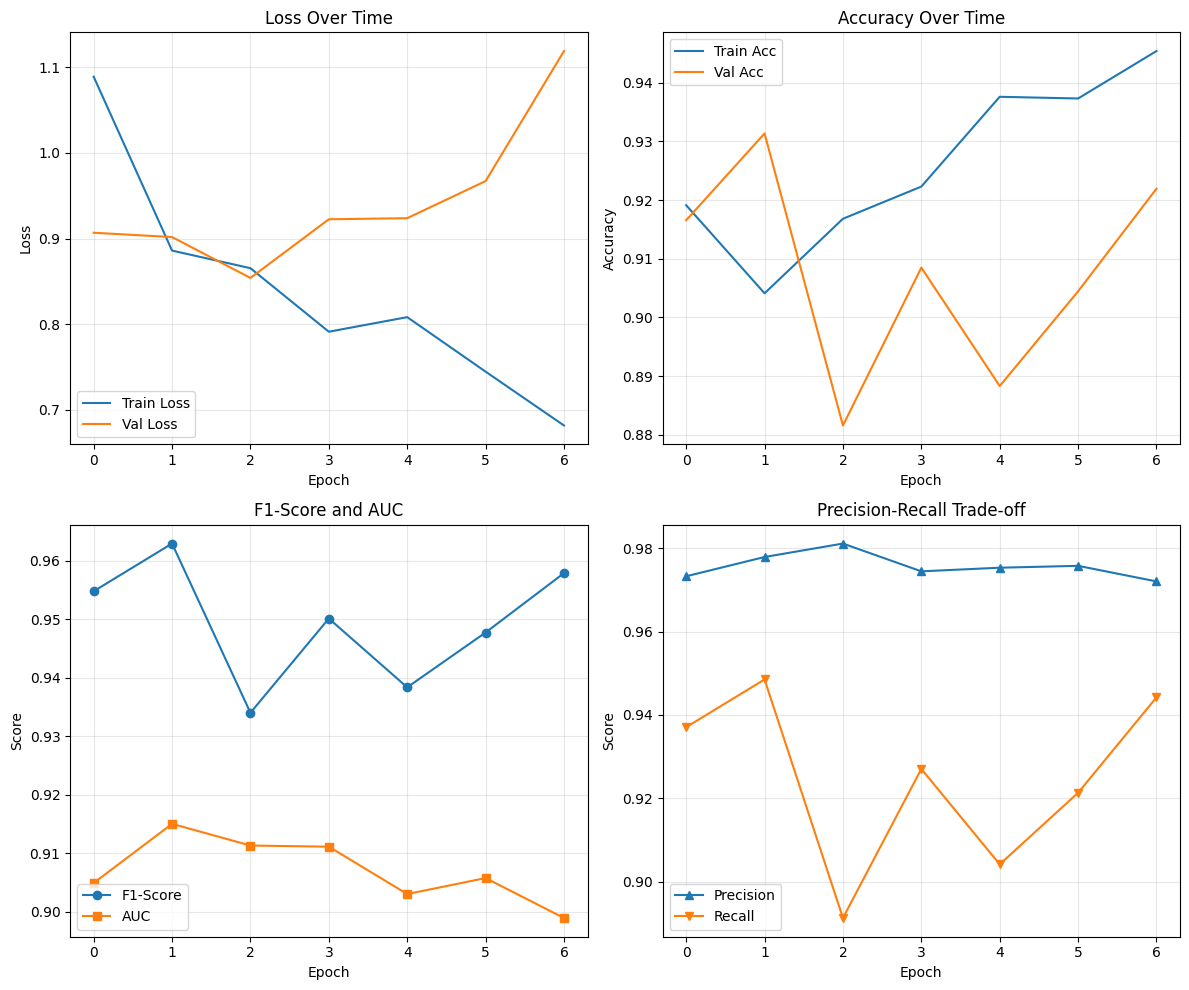

✅ Training history plot saved to ../../reports/cafe/training_history.png


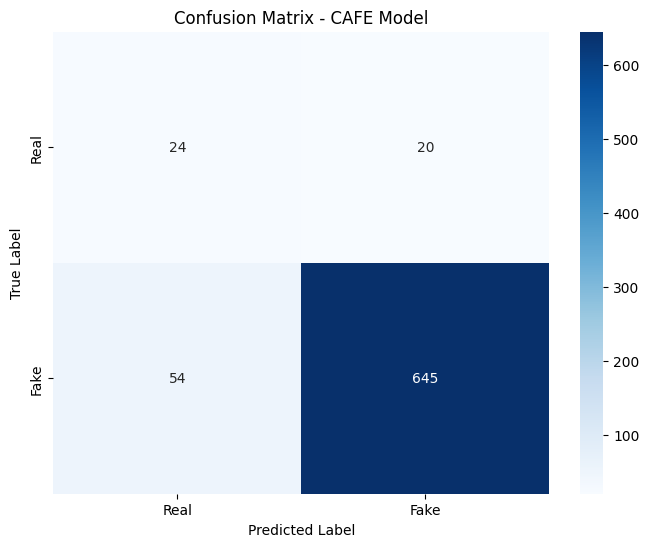

✅ Confusion matrix saved to ../../reports/cafe/confusion_matrix.png


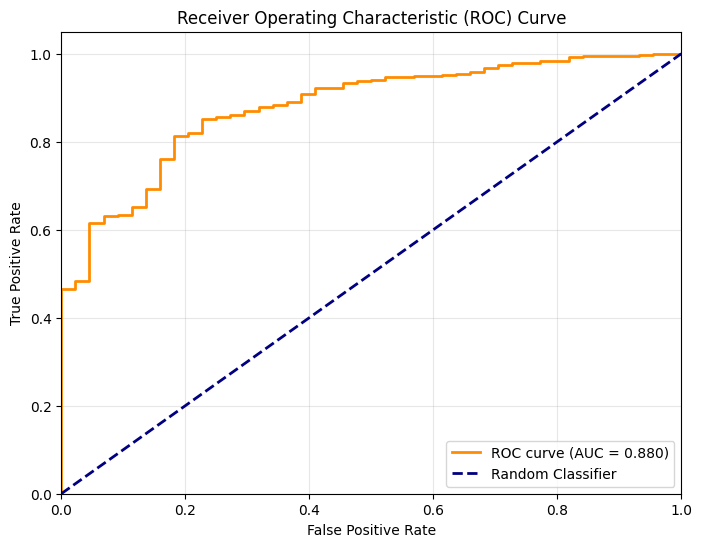

✅ ROC curve saved to ../../reports/cafe/roc_curve.png


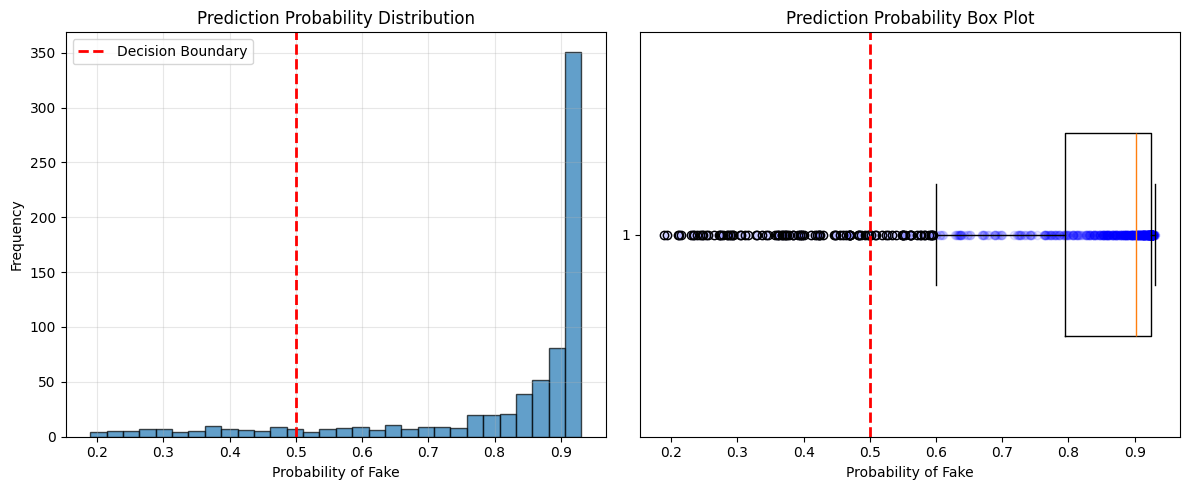

✅ Prediction distribution saved to ../../reports/cafe/prediction_dist.png


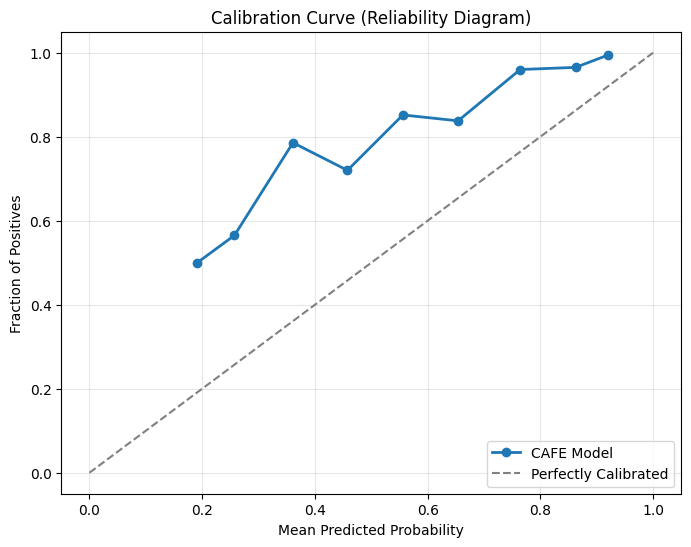

✅ Calibration curve saved to ../../reports/cafe/calibration_curve.png


In [18]:
CAFEVisualizer.plot_training_history(metrics_history, '../../reports/cafe/training_history.png')
CAFEVisualizer.plot_confusion_matrix(test_metrics['true_labels'], test_metrics['predictions'], '../../reports/cafe/confusion_matrix.png')
CAFEVisualizer.plot_roc_curve(test_metrics['true_labels'], test_metrics['probabilities'], '../../reports/cafe/roc_curve.png')
CAFEVisualizer.plot_prediction_distribution(test_metrics['probabilities'], '../../reports/cafe/prediction_dist.png')
CAFEVisualizer.plot_calibration_curve(test_metrics['true_labels'], test_metrics['probabilities'], '../../reports/cafe/calibration_curve.png')